In [45]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

API_KEY = "a944da"
search_name = "Inception"

all_movies = []

for page in range(1, 6):  
    url = f"http://www.omdbapi.com/?apikey={API_KEY}&s={search_name}&page={page}"
    response = requests.get(url)
    data = response.json()
    
    if data["Response"] == "True":
        all_movies.extend(data["Search"])
    else:
        break

df = pd.DataFrame(all_movies)

print(df)
df.to_csv("all_movies.csv", index=False)

                                                Title   Year      imdbID  \
0                                           Inception   2010   tt1375666   
1                            Inception: The Cobol Job   2010   tt5295894   
2                                The Crack: Inception   2019   tt6793710   
3               Inception: Jump Right Into the Action   2010   tt5295990   
4                            Inception: Motion Comics  2010–   tt1790736   
5                                           Inception   2014   tt7321322   
6                                   Madness Inception   2022  tt29258696   
7                  Inception: 4Movie Premiere Special   2010   tt1686778   
8                               Cyberalien: Inception   2017   tt7926130   
9                                  WWA: The Inception   2001   tt0311992   
10                                   Bikini Inception   2015   tt8269586   
11                           Inception: In 60 Seconds   2013   tt3262402   
12          

PermissionError: [Errno 13] Permission denied: 'all_movies.csv'

In [ ]:
print("Total Movies:", len(df))

In [63]:
df["Year_clean"] = df["Year"].str.extract(r'(\d{4})')
df["Year_clean"] = pd.to_numeric(df["Year_clean"], errors="coerce")
print(df["Year_clean"].value_counts().sort_index())

Year_clean
2001    1
2009    1
2010    7
2011    6
2012    1
2013    3
2014    2
2015    1
2016    3
2017    4
2018    1
2019    2
2020    1
2021    2
2022    2
2023    3
2026    1
Name: count, dtype: int64


In [64]:
df["Year"] =pd.to_numeric(df["Year"],errors="coerce")
latest=df.sort_values("Year",ascending=False).head(1)
print(latest[["Title", "Year"]])

oldest=df.sort_values("Year").head(1)
print(oldest[["Title", "Year"]])

                               Title    Year
30  Omerta: From Inception to Screen  2026.0
                Title    Year
9  WWA: The Inception  2001.0


In [65]:
df.head(1)

,Title,Year,imdbID,Type,Poster,title_length,first_word,imdb_numeric,Year_clean
0,Inception,2010.0,tt1375666,movie,https://m.media-amazon.com/images/M/MV5BMjAxMz...,9,Inception,1375666,2010


In [66]:
print(df["Type"].value_counts())

Type
movie     38
series     2
game       1
Name: count, dtype: int64


In [67]:
movies=df[df["Type"]=="movie"]
print(movies.head())

                                   Title    Year     imdbID   Type  \
0                              Inception  2010.0  tt1375666  movie   
1               Inception: The Cobol Job  2010.0  tt5295894  movie   
2                   The Crack: Inception  2019.0  tt6793710  movie   
3  Inception: Jump Right Into the Action  2010.0  tt5295990  movie   
5                              Inception  2014.0  tt7321322  movie   

                                              Poster  title_length  \
0  https://m.media-amazon.com/images/M/MV5BMjAxMz...             9   
1  https://m.media-amazon.com/images/M/MV5BMjE0NG...            24   
2  https://m.media-amazon.com/images/M/MV5BZTc4MD...            20   
3  https://m.media-amazon.com/images/M/MV5BZGFjOT...            37   
5  https://m.media-amazon.com/images/M/MV5BOTY3OG...             9   

   first_word imdb_numeric  Year_clean  
0   Inception      1375666        2010  
1  Inception:      5295894        2010  
2         The      6793710        2

In [68]:
df["title_length"] = df["Title"].str.len()
longest_title=df.sort_values("title_length",ascending=False).head(1)
print(longest_title["Title"])

20    The Inception of Parasite at the Grand Chungki...
Name: Title, dtype: object


In [69]:
print("Unique IMDb IDs:", df["imdbID"].nunique())

Unique IMDb IDs: 41


In [70]:
max_year=df["Year_clean"].value_counts().idxmax()
print("Most Movies Year:", max_year)

Most Movies Year: 2010


In [71]:
print("Average Year:", df["Year_clean"].mean())

Average Year: 2014.9512195121952


In [72]:
after_2015=df[df["Year_clean"]>2015]
print("Movies after 2015:", len(after_2015))

Movies after 2015: 19


In [73]:
print(df.groupby("Type")["Year_clean"].mean())

Type
game      2014.000000
movie     2014.894737
series    2016.500000
Name: Year_clean, dtype: float64


In [74]:
print(df.sort_values("Year_clean", ascending=False).head(5)[["Title", "Year_clean"]])

                                                Title  Year_clean
30                   Omerta: From Inception to Screen        2026
27                             Announcement Inception        2023
28                                      Evo Inception        2023
23                               Inception of Silence        2023
20  The Inception of Parasite at the Grand Chungki...        2022


In [75]:
print(df.sort_values("Year_clean").head(5)[["Title", "Year_clean"]])

                                    Title  Year_clean
9                      WWA: The Inception        2001
35         Tu Tengo: Victoria's Inception        2009
3   Inception: Jump Right Into the Action        2010
0                               Inception        2010
7      Inception: 4Movie Premiere Special        2010


In [76]:
print("Oldest Year:", df["Year_clean"].min())
print("Newest Year:", df["Year_clean"].max())

Oldest Year: 2001
Newest Year: 2026


In [77]:
df["Decade"] = (df["Year_clean"] // 10) * 10
print(df["Decade"].value_counts().sort_index())

Decade
2000     2
2010    30
2020     9
Name: count, dtype: int64


In [78]:
df["first_word"] = df["Title"].str.split().str[0]
print(df["first_word"].value_counts().head(10))

first_word
Inception      11
Inception:      5
The             4
Madness         1
Cyberalien:     1
WWA:            1
Bikini          1
Insha           1
On              1
Needle          1
Name: count, dtype: int64


In [79]:
long_titles = df[df["Title"].str.len() > 15]
print(long_titles["Title"])

1                              Inception: The Cobol Job
2                                  The Crack: Inception
3                 Inception: Jump Right Into the Action
4                              Inception: Motion Comics
6                                     Madness Inception
7                    Inception: 4Movie Premiere Special
8                                 Cyberalien: Inception
9                                    WWA: The Inception
10                                     Bikini Inception
11                             Inception: In 60 Seconds
12                Insha Allah - An inception at closure
13                           On Inception (TOI and MOI)
14                                Needle Drop Inception
17                                   Inception Premiere
19                           Jackass Parody - Inception
20    The Inception of Parasite at the Grand Chungki...
21                                     Inception (2010)
22    I Forgot the Notations which were Excellen

In [80]:
df["imdb_numeric"] = df["imdbID"].str.replace("tt", "")
print(df["imdb_numeric"].head())

0    1375666
1    5295894
2    6793710
3    5295990
4    1790736
Name: imdb_numeric, dtype: object


In [81]:
print(df.sample(5)[["Title", "Year_clean"]])

                             Title  Year_clean
35  Tu Tengo: Victoria's Inception        2009
32              Inception (Sweded)        2011
37              Inception Hanukkah        2011
21                Inception (2010)        2010
27          Announcement Inception        2023


In [82]:
df["title_length"] = df["Title"].str.len()
print(df[["Year_clean", "title_length"]].corr())

              Year_clean  title_length
Year_clean       1.00000       0.20645
title_length     0.20645       1.00000


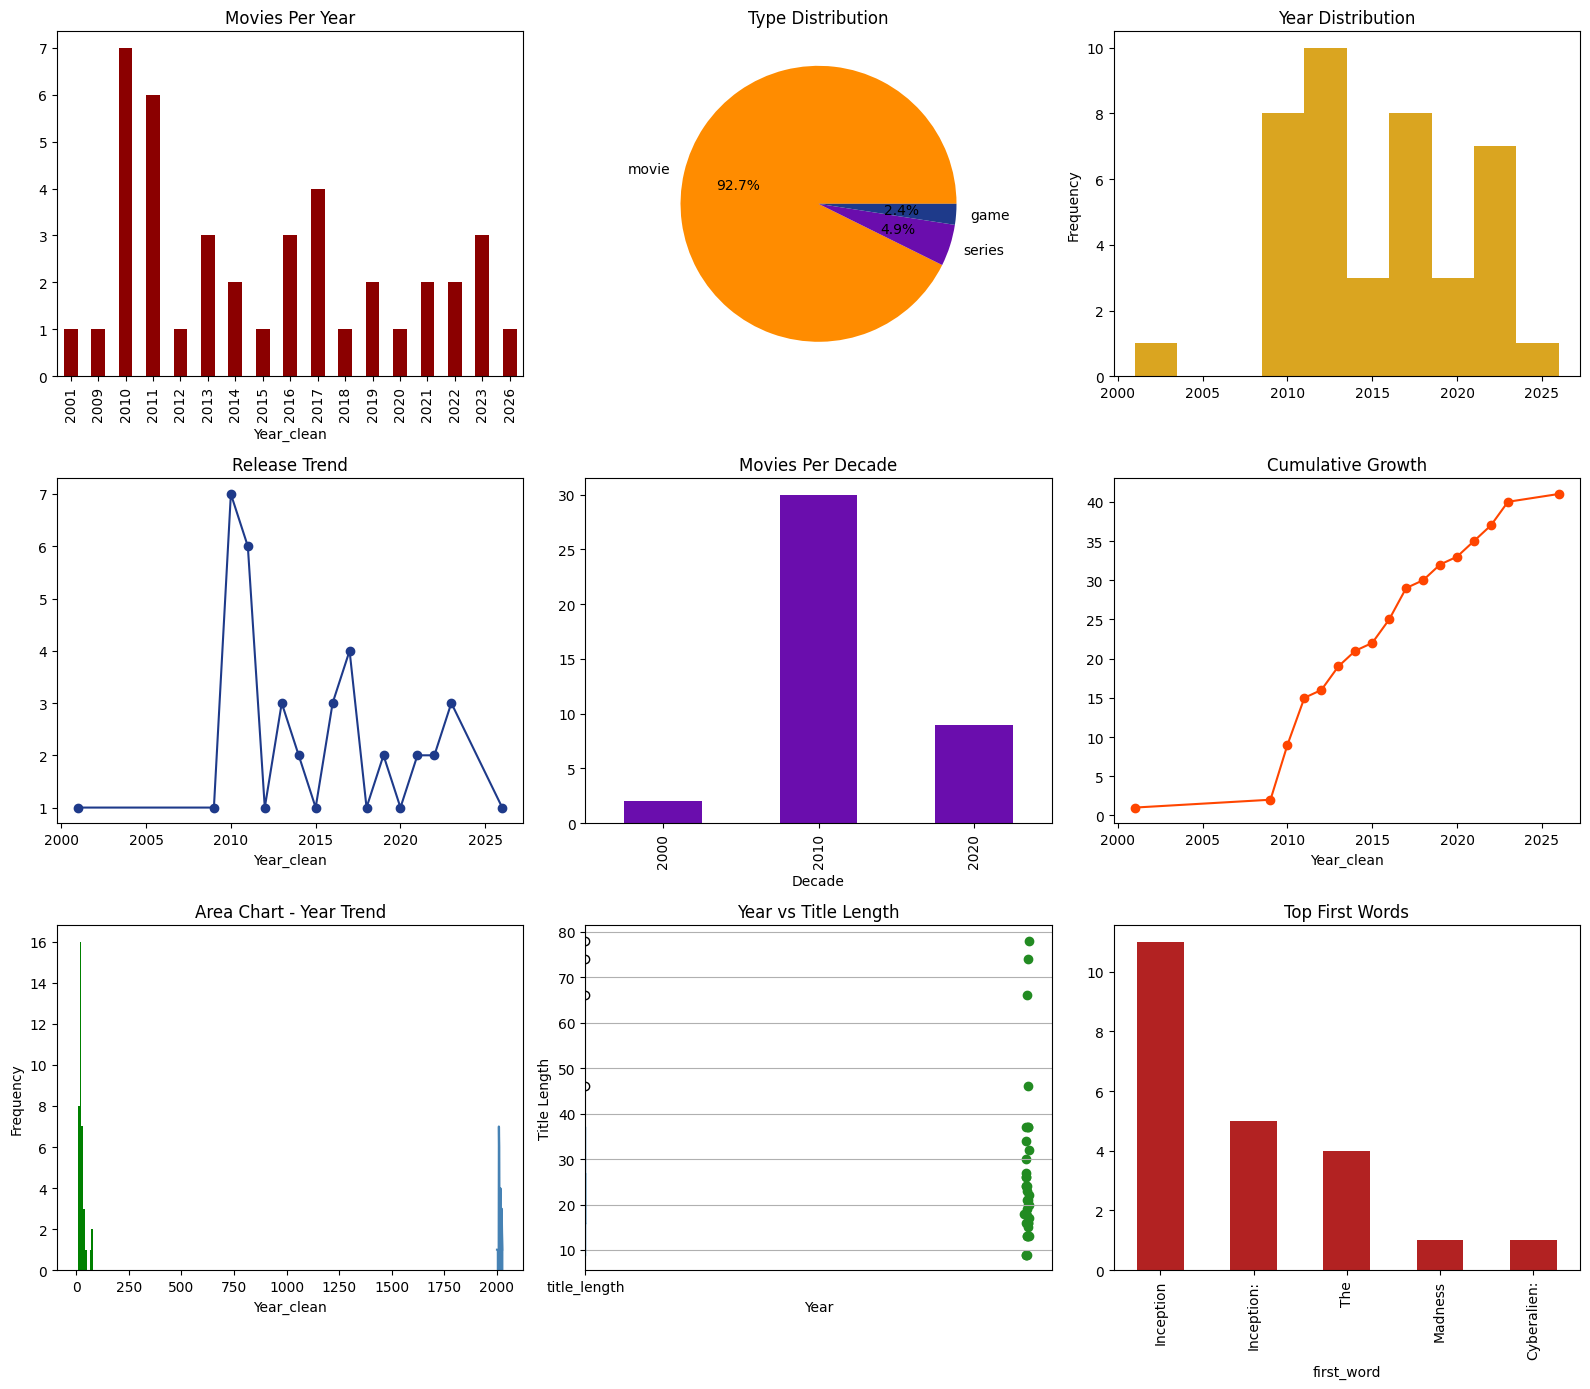

In [94]:
plt.figure(figsize=(16,14))

plt.subplot(3,3,1)
df["Year_clean"].value_counts().sort_index().plot(kind="bar", color="#8B0000")
plt.title("Movies Per Year")

plt.subplot(3,3,2)
df["Type"].value_counts().plot(kind="pie", autopct="%1.1f%%",  colors=["#FF8C00", "#6A0DAD", "#1E3A8A"])
plt.title("Type Distribution")
plt.ylabel("")

plt.subplot(3,3,3)
df["Year_clean"].plot(kind="hist", bins=10, color="#DAA520")
plt.title("Year Distribution")

plt.subplot(3,3,4)
df["Year_clean"].value_counts().sort_index().plot(kind="line",color="#1E3A8A", marker="o")
plt.title("Release Trend")

plt.subplot(3,3,5)
df["Decade"].value_counts().sort_index().plot(kind="bar",color="#6A0DAD")
plt.title("Movies Per Decade")

plt.subplot(3,3,6)
year_counts = df["Year_clean"].value_counts().sort_index()
year_counts.cumsum().plot(kind="line",color="#FF4500", marker="o")
plt.title("Cumulative Growth")

plt.subplot(3,3,7)
df["title_length"].plot(kind="hist", bins=10,color="green")
plt.title("Title Length Distribution")

plt.subplot(3,3,8)
df.boxplot(column="title_length")
plt.title("Title Length Boxplot")

plt.subplot(3,3,7)
df["Year_clean"].value_counts().sort_index().plot(kind="area",color="#4682B4")
plt.title("Area Chart - Year Trend")

plt.subplot(3,3,8)
plt.scatter(df["Year_clean"], df["title_length"],color="#228B22")
plt.title("Year vs Title Length")
plt.xlabel("Year")
plt.ylabel("Title Length")

plt.subplot(3,3,9)
df["first_word"].value_counts().head(5).plot(kind="bar",color="#B22222")
plt.title("Top First Words")


plt.tight_layout()
plt.show()